# Week 1 — 오리엔테이션: 데이터로 결정한다는 것

**Business Analytics · 산업공학과 4학년 · 2026 · Cookie Cats A/B 테스트 실데이터**

이 장은 모바일 게임사가 남긴 실험 기록 한 벌을 연다. 데이터가 어떻게 만들어졌는지 확인하고
탐색한 뒤, 그 데이터로 무엇을 결정할 수 있는지 문제를 세우고, 전공에서 배운 검정으로 답한
다음, 그 답을 금액으로 옮겨 권고로 끝맺는다. 이 순서가 매주 반복된다.

> **실습본이다.** 첫 셀(데이터 준비)을 빼고 코드 셀이 전부 비어 있다. 각 셀의 주석이 무엇을
> 할지 알려 주고, 바로 위 지시문이 그 이유를 설명한다. 수업 중 교수와 함께 한 셀씩 타이핑해
> 채운다. 코드가 채워진 판은 따로 배포하지 않으므로, 수업이 끝나면
> **"파일 → Drive에 사본 저장"** 으로 직접 채운 노트북을 각자 보관한다.

## 1. 데이터 — 출처와 수집 경위

덴마크의 모바일 게임사 Tactile Entertainment가 만든 퍼즐 게임 Cookie Cats에는 게이트(gate)가
있다. 일정 레벨에 도달하면 게임이 잠시 멈추고, 유저는 기다리거나 결제해야 다음 레벨로
넘어간다. 이 강제 대기 지점을 어디에 둘지가 매출과 직결되는데, 회의실의 직관만으로는
결론이 나지 않아 회사는 실험을 돌렸다.

**어떻게 기록되었는가.** 신규 설치 유저가 게임을 처음 켤 때 서버가 그 유저를 두 그룹 중
하나에 무작위로 배정하고(게이트를 레벨 30에 두는 그룹과 40에 두는 그룹), 배정 결과를 유저
식별자와 함께 저장했다. 이후 14일 동안 각 유저의 플레이 판 수가 누적 집계되고, 설치 1일
뒤와 7일 뒤에 접속했는지가 각각 기록됐다. 즉 이 데이터는 설문이나 관찰이 아니라 **제품에
심어 둔 실험 장치가 자동으로 남긴 로그**다.

**무엇이 통제되었는가.** 배정은 사람이 고르지 않고 무작위로 이뤄졌다. 그래서 두 그룹은
게이트 위치를 빼면 나이·실력·과금 성향 같은 다른 조건이 통계적으로 비슷하다고 기대할 수
있다. 이 성질이 뒤에서 차이를 게이트의 효과로 해석할 근거가 된다.

**무엇이 기록되지 않았는가.** 과금액, 유저의 국가·기기, 이탈 사유는 이 데이터에 없다.
따라서 이 장의 결정은 잔존율까지만 다루고, 매출 환산은 별도의 가정을 명시해 수행한다.

데이터 확보(다운로드·캐시)는 `balab.load`가 처리한다.

## 2. 데이터 탐색

새 데이터를 받으면 아래 순서를 그대로 돌린다. 확인마다 제목을 두고, 그 안의 작은 단계는 **확인
번호-단계 번호**(예: 4-2)로 매긴다. 단계마다 **할 일**이 한 문장으로 적혀 있고, 코드 셀의 주석에 쓸
함수가 적혀 있다. 실습본에서는 첫 셀을 빼고 모든 코드 셀이 비어 있으며 수업 중 함께 채운다.
코드 뒤의 **함의**는 결과가 결정에 무엇을 뜻하는지다.

| | 확인할 것 | 왜 |
|---|---|---|
| 1 | 크기와 한 행의 의미 | 분석 단위를 정한다 |
| 2 | 컬럼의 자료형과 역할 | 처치·결과·보조를 가른다 |
| 3 | 식별자 중복과 결측 | 집계가 부풀거나 새는지 본다 |
| 4 | 그룹별 표본 수 | 비교의 기반을 확인한다 |
| 5 | 참여 지표의 분포 | 극단값을 찾아 자르고, 그룹별로 나눠 본다 |
| 6 | 두 결과 지표의 관계 | 지표의 정의를 확인한다 |

---
### 확인 1. 데이터를 불러와 크기와 생김새를 본다

**1-1. 할 일** — 첫 셀을 실행한다. 공용 코드 `balab`을 준비하고 `load`로 데이터를 읽어 `cc`에 담는 셀이며, 이 셀만 채워져 있다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import os
import sys
for _p in (".", "..", "../.."):
    if os.path.exists(os.path.join(_p, "balab.py")):
        sys.path.insert(0, _p); break
else:
    !wget -q https://raw.githubusercontent.com/BALAB-PKNU/bizanalytics/main/balab.py

from balab import load
cc = load("cookie_cats")

In [2]:
cc

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
...,...,...,...,...,...
90184,9999441,gate_40,97,True,False
90185,9999479,gate_40,30,False,False
90186,9999710,gate_30,28,True,False
90187,9999768,gate_40,51,True,False


**1-2. 할 일** — `cc`를 이름만 쳐서 출력한다. 맨 아래에 찍히는 행·열 수를 읽는다.

In [ ]:
# 1-2. 데이터프레임을 이름만 쳐서 출력한다

> **함의.** 90,189행 5열이고, 한 행은 신규 설치 유저 한 명이다. **분석 단위는 유저**이며,
> 이후 모든 집계는 이 단위를 기준으로 한다.

---
### 확인 2. 각 열의 자료형과 역할을 확인한다

In [3]:
cc.dtypes

,0
userid,int64
version,object
sum_gamerounds,int64
retention_1,bool
retention_7,bool


**2-1. 할 일** — `cc.dtypes`로 열마다 자료형을 출력하고, 아래 표대로 각 열을 처치·결과·보조로 분류한다.

| 컬럼 | 의미 | 역할 |
|---|---|---|
| `userid` | 유저 고유 번호 | 식별자 |
| `version` | `gate_30`(게이트 레벨 30) 또는 `gate_40`(레벨 40) | **처치** |
| `sum_gamerounds` | 설치 후 14일간 플레이한 판 수 | 보조(참여) |
| `retention_1` | 설치 1일 후 재접속 여부 | **결과** |
| `retention_7` | 설치 7일 후 재접속 여부 | **결과** |

In [ ]:
# 2-1. 열마다 자료형을 본다 (dtypes)

> **함의.** `retention_1`·`retention_7`이 불리언이므로 `mean()`이 곧 재접속 비율이다 —
> 잔존율 집계가 한 줄로 끝난다. `userid`는 정수로 읽히지만 크기에 의미가 없는 식별자라
> 더하거나 평균 내지 않는다.

---
### 확인 3. 식별자 중복과 결측을 점검한다

**3-1. 할 일** — `len`으로 `cc`의 행 수를 출력한다.

In [4]:
len(cc)

90189

In [ ]:
# 3-1. 행 수를 센다 (len)

**3-2. 할 일** — `userid` 열의 `nunique`로 서로 다른 유저 수를 출력한다. 3-1과 같으면 중복이 없다.

In [9]:
cc['userid'].nunique()

90189

In [ ]:
# 3-2. 서로 다른 userid 수를 센다 (nunique)

**3-3. 할 일** — `isna()`로 칸마다 비었는지의 참·거짓을 만들고 `.sum()`을 붙여 열별 결측 수를 출력한다.

In [10]:
cc.isna().sum()

,0
userid,0
version,0
sum_gamerounds,0
retention_1,0
retention_7,0


In [ ]:
# 3-3. 열별 결측 수를 센다 (isna 뒤에 sum)

> **함의.** 고유 `userid` 수가 행 수와 같아 유저가 중복 없이 한 번씩 기록됐고, 모든 열의
> 결측이 0이다. 조인으로 행이 부풀거나 결측 처리 규칙을 정할 일이 없다는 뜻이다. 실험
> 장치가 남긴 로그라 가능한 상태이며, 뒤 주차의 거래·센서 데이터는 사정이 다르다.

---
### 확인 4. 두 그룹의 표본 수를 센다

**4-1. 할 일** — `version` 열의 `unique()`로 어떤 값이 있는지 출력한다.

In [11]:
# 4-1. version 열의 서로 다른 값을 나열한다 (unique)
cc['version'].unique()

array(['gate_30', 'gate_40'], dtype=object)

**4-2. 할 일** — `cc["version"] == "gate_30"`을 실행해 행마다 참·거짓이 나오는 것을 본다.

In [12]:
# 4-2. version이 gate_30인지 행마다 참·거짓으로 본다 (== 비교)
cc["version"] == "gate_30"

,version
0,True
1,True
2,False
3,False
4,False
...,...
90184,False
90185,False
90186,True
90187,False


**4-3. 할 일** — 4-2의 참·거짓 전체를 괄호로 싸고 `.sum()`을 붙여 gate_30 유저 수를 출력한다. True는 1로 계산된다.

In [14]:
# 4-3. 위 참·거짓을 더해 gate_30 유저 수를 센다 (sum)
(cc["version"] == "gate_30").sum()

np.int64(44700)

**4-4. 할 일** — 같은 참·거짓 식을 `cc[ ]` 대괄호 안에 넣어 gate_40인 행만 골라 출력한다. 맨 아래 행 수가 gate_40 유저 수다.

In [15]:
# 4-4. gate_40인 행만 골라낸다 (대괄호 안에 조건)
cc[cc["version"] == "gate_40"]

,userid,version,sum_gamerounds,retention_1,retention_7
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
5,540,gate_40,187,True,True
7,1444,gate_40,2,False,False
...,...,...,...,...,...
90181,9998733,gate_40,10,True,False
90184,9999441,gate_40,97,True,False
90185,9999479,gate_40,30,False,False
90187,9999768,gate_40,51,True,False


**4-5. 할 일** — `version` 열의 `value_counts()`로 값마다 개수를 한 줄에 출력하고 4-3·4-4와 같은지 확인한다.

In [16]:
# 4-5. 값마다 개수를 한 줄로 센다 (value_counts)
cc["version"].value_counts()

,count
version,
gate_40,45489
gate_30,44700


> **함의.** 44,700 대 45,489로 정확히 반반은 아니다. 유저마다 동전을 던지듯 배정하면
> 표본 수는 우연히 어긋나며, 이 정도는 무작위 배정에서 자연스럽다. 두 그룹의 크기가
> 비슷해 비교의 정밀도도 비슷하다.

---
### 확인 5. 참여 지표(판수)의 분포를 본다

4절에서 "무엇으로 잴 것인가"를 정할 때 판수를 지표로 쓸 수 있는지 판단해야 한다. 그 재료를 여기서 만든다.
순서는 새 수치 열을 받았을 때 늘 밟는 순서다 — 요약 통계를 보고, 그림을 그려 보고, 안 보이면 왜 안 보이는지 찾고,
자른 뒤 다시 그리고, 그룹별로 나눠 그린다.

**5-1. 할 일** — `sum_gamerounds` 열의 `describe()`로 개수·평균·표준편차·최소·사분위수·최대를 출력한다.

In [17]:
# 5-1. 판수 열의 요약 통계를 본다 (describe)
cc['sum_gamerounds'].describe()

,sum_gamerounds
count,90189.000000
mean,51.872457
std,195.050858
min,0.000000
25%,5.000000
50%,16.000000
75%,51.000000
max,49854.000000


통계량 분석: 메크로 돌린 사람 때문에 평균이 중앙값에 비해 훨씬 큼

> **함의.** 중앙값은 16판인데 평균은 51.9판이고 최댓값은 49,854판이다. 평균이 중앙값의 세 배가 넘고 최댓값이
> 평균의 천 배에 가깝다. 분포가 한쪽으로 크게 치우쳐 있다. 모양은 그림으로 확인한다.

**5-2. 할 일** — `plt.hist(cc["sum_gamerounds"])` 한 줄만 실행한다. 그림 위에 숫자 배열이 함께 찍히는 것을 본다.

(array([9.0188e+04, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([    0. ,  4985.4,  9970.8, 14956.2, 19941.6, 24927. , 29912.4,
        34897.8, 39883.2, 44868.6, 49854. ]),
 <BarContainer object of 10 artists>)

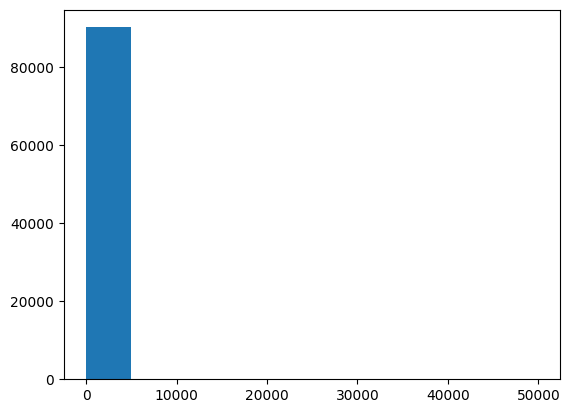

In [19]:
# 5-2. 판수의 히스토그램을 한 줄로 그린다 (plt.hist)
plt.hist(cc["sum_gamerounds"])

> **함의.** 막대가 왼쪽 끝 하나뿐이다. 가로축이 49,854까지 늘어나 첫 구간에 유저 거의 전부가 들어간다. 5-2에 찍힌
> 배열이 그 증거다 — 첫 구간 개수가 90,188이고 나머지 구간은 0 또는 1이다. 극단값이 그림을 망친다. 그 극단값이 어디까지
> 있는지부터 본다.

**5-3. 할 일** — `cc.sort_values("sum_gamerounds", ascending=False).head(10)`으로 판수 내림차순 상위 열 행을 출력한다.

In [21]:
# 5-3. 판수 내림차순으로 정렬해 위 열 행을 본다 (sort_values, head)
cc.sort_values("sum_gamerounds", ascending=False).head(10)

,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True
7912,871500,gate_30,2961,True,True
29417,3271615,gate_40,2640,True,False
43671,4832608,gate_30,2438,True,True
48188,5346171,gate_40,2294,True,True
46344,5133952,gate_30,2251,True,True
87007,9640085,gate_30,2156,True,True
36933,4090246,gate_40,2124,True,True
88328,9791599,gate_40,2063,True,True
6536,725080,gate_40,2015,True,True


> **함의.** 1위가 49,854판이고 2위는 2,961판이다. 1위와 2위 사이가 17배다. 14일에 49,854판은 하루 3,500판이 넘는다.
> 그 아래로는 2,000판대가 몇 명 이어진다. 한 명이 아니라 소수의 극단값이 있다.

**5-4. 할 일** — 극단값이 전체의 몇 %인지 분위수로 본다. `열.quantile(p)`는 값의 p 비율이 그 이하가 되는 경계다.
처음 나오는 함수이므로 작은 예로 먼저 본다. `pd.Series([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).quantile(0.9)`를 출력한다.

In [23]:
# 5-4. 1~10 열 개 값의 0.9 분위수를 본다 (pd.Series, quantile)
pd.Series([1,2,3,4,5,6,7,8,9,10]).quantile(0.9)

np.float64(9.1)

**5-5. 할 일** — `cc["sum_gamerounds"].quantile([0.5, 0.9, 0.99, 0.999])`를 출력한다. 목록을 주면 분위수 여러 개가 한 번에 나온다.

In [24]:
# 5-5. 판수의 0.5, 0.9, 0.99, 0.999 분위수를 한 번에 본다 (quantile에 목록)
cc["sum_gamerounds"].quantile([0.5,0.9,0.99,0.999])

,sum_gamerounds
0.500,16.000
0.900,134.000
0.990,493.000
0.999,1073.624


> **함의.** 유저의 절반은 16판 이하, 90%는 134판 이하, 99%는 493판 이하다. 그 위 1%가 2,000판대와 49,854판까지 늘어져
> 있다. 상위 1%를 잘라내면 나머지 99%의 모양을 볼 수 있다.

**5-6. 할 일** — `cut = cc["sum_gamerounds"].quantile(0.99)`로 경계를 두고, 판수가 `cut` 이하인 행만 남긴 표를 `trim`에 담는다
(확인 4-4의 조건 필터). `len(cc) - len(trim)`으로 빠진 유저 수를 출력한다.

In [26]:
# 5-6. cut = 판수의 0.99 분위수, trim = 판수가 cut 이하인 행 (조건 필터). 빠진 유저 수
cut = cc["sum_gamerounds"].quantile(0.99) ## 99 분위수
cc["sum_gamerounds"] < cut ## 99분위수보다 작은 데이터만 골라라
trim = cc[cc["sum_gamerounds"] < cut] ##99분위수(게임판수)보다 적게 게임한 사람의 데이터만 골라서 트림 변수에 저장해라
len(cc) - len(trim)

906

**5-7. 할 일** — `trim`으로 히스토그램을 다시 그린다. 여섯 줄 뼈대다. `plt.figure(figsize=(8, 4))`로 크기를 정하고,
`plt.hist(trim["sum_gamerounds"], bins=50)`, `plt.xlabel`, `plt.ylabel`, `plt.title`로 축 이름과 제목을 붙이고, `plt.show()`로 끝낸다.
`bins=50`은 구간 수이고 `plt.show()`는 5-2에 찍히던 배열을 숨긴다. 이 뼈대가 이 장의 모든 그림에 반복된다.

Text(0.5, 1.0, 'game rounds distribution of under 99% percentile')

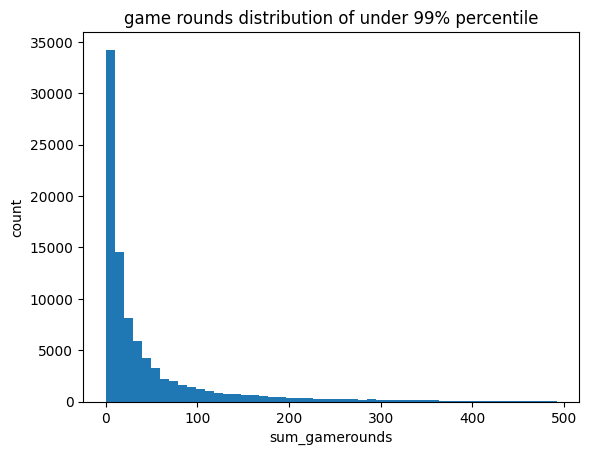

In [29]:
# 5-7. 크기 → trim의 히스토그램(bins=50) → 축 이름 둘 → 제목 → 표시 (figure, hist, xlabel, ylabel, title, show)
plt.hist(trim['sum_gamerounds'],bins=50)
plt.xlabel('sum_gamerounds') # x축 추가
plt.ylabel('count') # y축 추가
plt.title('game rounds distribution of under 99% percentile') # 타이틀 표시

> **함의.** 이제 모양이 보인다. 0~10판 구간이 가장 높고 오른쪽으로 길게 꼬리가 이어진다. 몇 판 만에 떠나는 유저가
> 가장 흔하고 소수가 오래 한다. 상위 1%를 잘라도 꼬리는 남는다 — 이 분포에서 평균은 꼬리에 끌려간 값이지 보통 유저를
> 대표하는 값이 아니다.

**5-8. 할 일** — 같은 그림을 그룹별로 겹쳐 그린다. `trim`에서 gate_30인 행의 판수와 gate_40인 행의 판수를 각각 `plt.hist`로
그리되 `bins=50`, `alpha=0.5`(반투명), `label="gate_30"`/`label="gate_40"`을 주고 `plt.legend()`를 붙인다. 나머지 뼈대는 5-7과 같다.

Text(0.5, 1.0, 'Game rounds by gate (top 1% removed)')

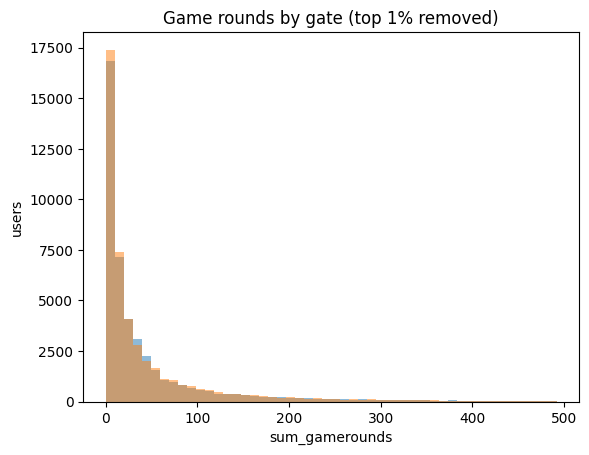

In [31]:
# 5-8. 두 그룹의 판수 히스토그램을 반투명(alpha)으로 겹쳐 그리고 범례를 붙인다 (조건 필터, hist에 alpha·label, legend)
gate30 = trim[trim['version'] == 'gate_30']
gate40 = trim[trim['version'] == 'gate_40']
plt.hist(gate30['sum_gamerounds'],alpha=0.5, bins=50, label='gate_30') # lable은 히스토그램에 범례를 추가하는 옵션
plt.hist(gate40['sum_gamerounds'],alpha=0.5, bins=50, label='gate_40') # alpha눈 그래프의 투명도를 조정하는 옵션
plt.xlabel('sum_gamerounds')
plt.ylabel('users')
plt.title("Game rounds by gate (top 1% removed)")

> **함의.** 두 그룹의 분포가 거의 포개진다. 게이트 위치가 판수의 분포를 눈에 띄게 바꾸지는 않는다. 그렇다면 판수의
> 평균으로 게이트 효과를 잴 수 있는가 — 극단값 소수가 평균을 흔드는 분포라는 것이 여기서 확인됐으니, 4절에서 데이터로
> 판정한다.

---
### 확인 6. 두 잔존 지표의 교차표로 지표의 정의를 확인한다

`pd.crosstab(행으로 쓸 열, 열로 쓸 열)`은 두 열의 값 조합마다 행 수를 센다. 처음 나오는 함수이므로 작은 예로 먼저 본다.

**6-1. 할 일** — `pd.crosstab(["a", "a", "b", "b", "b"], [True, False, True, True, False])`를 출력한다. 첫 목록이 행, 둘째 목록이
열이 되어 조합마다 개수가 센다.

In [ ]:
# 6-1. 작은 두 목록으로 조합별 개수 표를 만들어 본다 (pd.crosstab)

**6-2. 할 일** — `pd.crosstab(cc["retention_1"], cc["retention_7"], normalize="all", margins=True) * 100`으로 두 잔존 지표의 교차표를
전체 대비 %로 출력한다. `normalize="all"`은 표 전체의 합이 1이 되게 나누고, `margins=True`는 행·열 합계를 붙인다.

In [32]:
# 6-2. 두 잔존 열의 교차표를 전체 대비 %로, 행·열 합계와 함께 만든다 (pd.crosstab, normalize, margins)
import pandas as pd
pd.crosstab(cc["retention_1"], cc["retention_7"], normalize="all", margins=True) * 100

retention_7,False,True,All
retention_1,,,
False,51.488541,3.990509,55.47905
True,29.904977,14.615973,44.52095
All,81.393518,18.606482,100.00000


> **함의.** 설치 유저의 51.5%는 1일에도 7일에도 돌아오지 않는다. 1일에 돌아온 유저의
> 7일 잔존율은 32.8%로, 오지 않은 유저(7.2%)의 4.6배다 — 두 지표는 강하게 겹친다. 다만
> 1일에는 안 왔다가 7일에 돌아온 유저도 4.0% 있는데, `retention_7`이 "7일 동안 잔존"이
> 아니라 **"설치 7일 뒤 시점의 재접속"** 을 재는 지표이기 때문이다. 지표의 정의를 확인하지
> 않으면 해석이 어긋난다.

---
### 탐색 요약

| 확인한 것 | 결과 | 결정에 주는 제약 |
|---|---|---|
| 단위 | 유저 1명 = 1행, 90,189명 | 유저 단위로 집계한다 |
| 품질 | 식별자 중복 0, 결측 0 | 정제 없이 바로 분석한다 |
| 배정 | 44,700 대 45,489 | 두 그룹을 대등하게 비교할 수 있다 |
| 참여 | 중앙값 16판, 상위 1%(493판 초과) 898명이 49,854판까지 | 평균 판수는 극단값에 흔들린다. 두 그룹 분포는 겹친다 |
| 결과 | 1일 44.5%, 7일 18.6%, 두 지표 강한 연관 | 비율 지표라 극단값에 강건하다 |
| 지표 정의 | `retention_7`은 7일째 재접속 여부 (확인 6) | 장기 잔존을 재는 지표로 쓸 수 있다 |

어느 지표로 결정할지는 아직 정하지 않았다. 4절에서 질문을 세우고 데이터로 정한다.

### ✏️ 직접 해보기 — 체크리스트를 다른 열에 적용 (약 10분)

`COL`을 바꿔 가며 위 절차를 다른 열에 그대로 돌린다. 범주형이면 `value_counts`로 값별 개수를, 수치형이면
`describe`로 범위와 사분위수를 본다.

1. `COL = "retention_1"`로 두고, 나온 True 비율이 5절에서 쓸 잔존율과 어떻게 이어지는지 예측해 보라.
2. `COL = "sum_gamerounds"`로 두고 `describe`를 써서, 이 요약만 보고 확인 5의 히스토그램 모양을 그릴 수 있는지
   따져 보라. 표가 놓치는 것은 무엇인가.

In [ ]:
# 직접 해보기 — COL에 열 이름을 넣고 그 열의 값별 개수를 센다 (value_counts). 수치형이면 describe


## 3. 풀고자 하는 문제

탐색으로 데이터의 형태를 알았으니, 이 데이터로 무엇을 정할 수 있는지 묻는다. 기록된 것은
게이트 위치(처치)와 잔존 여부(결과)이므로, 답할 수 있는 문제는 게이트 위치의 선택이다.
현재 게이트는 레벨 30에 있고 개발팀에는 이를 40으로 미루자는 제안이 올라와 있다. 게이트를
미루면 유저가 더 오래 즐기다 멈추니 정이 들어 남는다는 주장과, 강제 휴식을 뒤로 미루면
오히려 미리 지쳐 떠난다는 반대 주장이 맞선다.

> ### 이번 주의 의사결정 질문
> **"게임의 게이트를 레벨 30에 유지할까, 레벨 40으로 옮길까?"**

이 질문은 결정으로 이어진다. 답이 두 대안 중 하나로 좁혀지고, 회사는 어느 쪽이든 실제로
실행할 수 있으며, 잔존율의 차이는 유저 가치를 통해 매출로 환산된다. 7절에서 그 환산까지
간다.

### 이 분석이 쓰이는 곳

제품 실험(A/B 테스트)은 게임·커머스·핀테크·구독 서비스의 **그로스·제품기획·마케팅·
데이터** 부서가 제품을 바꾸기 전에 그 변화가 지표를 올리는지 확인할 때 쓴다. 전형적인
상황은 다음과 같다.

- **기능 변경 판단**: 화면 배치·가격·튜토리얼·게이트 위치를 바꾸기 전에, 일부 유저에게만
  새 버전을 노출해 잔존율·결제율이 오르는지 본다. 이 장이 다루는 상황이다.
- **캠페인·추천 정책 비교**: 두 가지 추천 로직이나 프로모션을 무작위로 나눠 보내 어느 쪽이
  매출을 더 올리는지 측정한다.
- **롤아웃 결정**: 실험 결과를 근거로 새 버전을 전체 유저에게 확대할지, 되돌릴지 정한다.

Cookie Cats 데이터는 그중 첫 번째 상황 — 게이트라는 게임 기능의 변경 여부를 실험으로
판단하는 경우다.

### 이 장의 구성

1. 데이터 — 출처와 수집 경위
2. 데이터 탐색
3. 풀고자 하는 문제
4. 무엇으로 잴 것인가 — 지표 선택
5. 그룹별 잔존율 집계
6. 그룹 차이의 유의성 검정
7. 효과의 금액 환산
8. 분석가의 역할

**이론은 이 노트북에 없다.** 이 장에 필요한 이론 — 의사결정의 틀, A/B 테스트와 무작위 배정, 가설검정,
2표본 비율 z-검정, p-value, 신뢰구간 — 은 배경이론 문서
**[1주차 배경이론 — 그룹 비교 검정](https://balab-pknu.github.io/bizanalytics/theory/week01.html)** 에 있다. 수업 전에 읽고 문서 11절의 연습문제에 답을 적어
온다. 4~7절은 그 이론을 이 데이터에 적용하는 절차만 다룬다.

학습 목표: 질문 → 데이터 → 분석 → 결정 → 가치의 틀로 분석 문제를 바라보고, 결정 지표를 데이터로 고르며,
실제 A/B 데이터에 그룹 비교 검정을 배운 형식대로 적용해 판정하고, 효과를 금액으로 환산해 권고 문장으로
완결한다.

## 4. 무엇으로 잴 것인가 — 지표 선택

**질문.** 게이트 위치의 효과를 무엇으로 재야 하는가. 데이터에 후보가 셋 있다 — 14일간 판수(`sum_gamerounds`),
1일 잔존(`retention_1`), 7일 잔존(`retention_7`). 분석이 끝난 뒤 유리한 지표를 고르면 분석이 아니므로,
지표는 여기서 정하고 적어 둔 뒤 5절로 간다.

### 💬 확인할 것을 먼저 적는다 (수업 중 답한다)

1. 게이트를 옮기는 목적이 무엇인가. 세 후보 중 그 목적에 가장 가까운 지표는 무엇인가.
2. 확인 5에서 본 판수 분포의 모양이 두 그룹의 평균 판수 비교에 어떤 문제를 만드는가.
3. 그 문제가 실제로 생기는지 어떻게 확인하겠는가.

확인할 것은 두 가지다. **후보 지표의 그룹별 값이 몇 명의 극단값에 흔들리는가**(실행 1·2에서 데이터로 본다),
그리고 **지표의 정의가 결정에 맞는가**(확인 6에서 봤다). 이후 절차는 **지시 → 실행 → 함의** 순서이며, 과제는
**실행 N.** 제목으로 구분한다.

---
### 실행 1. 그룹별 평균 판수와 중앙값 판수를 비교한다

**1-1. 할 일** — `cc.groupby(열A)[열B].mean()`은 열A의 값이 같은 행끼리 묶어 묶음마다 열B의 평균을 낸다. `version`으로 묶어 `sum_gamerounds`의 `.mean()`을 출력한다.

In [ ]:
# 실행 1-1. 그룹으로 묶어 판수의 평균 (groupby, mean)

**1-2. 할 일** — 같은 묶음의 `.median()`을 출력한다.

In [ ]:
# 실행 1-2. 그룹으로 묶어 판수의 중앙값 (groupby, median)

> **함의.** 평균은 gate_30 52.5판, gate_40 51.3판으로 gate_30이 1.2판 높다. 중앙값은 17 대 16이다. 평균의
> 차이 1.2판이 극단값 한 명 때문인지 실행 2에서 확인한다.

---
### 실행 2. 판수 1위 한 명을 빼고 다시 비교한다

**2-1. 할 일** — 확인 5-3에서 본 1위(49,854판) 한 명만 빼 본다. 확인 4-4의 조건 필터로 판수가 최댓값(`cc["sum_gamerounds"].max()`)보다
작은 행만 남긴 표를 `sub`에 담고 `len(sub)`를 출력한다. 정확히 한 행이 빠져야 한다.

In [ ]:
# 실행 2-1. 판수가 최댓값보다 작은 행만 남긴 표 sub (조건 필터, max)

**2-2. 할 일** — `sub`에서 실행 1-1과 같은 그룹별 평균 판수를 출력한다.

In [ ]:
# 실행 2-2. sub에서 그룹별 판수 평균 (groupby, mean)

> **함의.** 한 명을 빼자 gate_30의 평균이 52.5에서 51.3으로 내려와 두 그룹이 같아진다(51.34 대 51.30). 실행
> 1-1의 우열 1.2판은 유저 90,189명 중 한 명이 만든 것이다. 판수의 평균은 지표로 쓸 수 없다.

### 지표를 정한다

| 후보 | 극단값에 대한 강건성 | 게이트의 목적과의 대응 | 판정 |
|---|---|---|---|
| 판수 평균 | 한 명이 우열을 뒤집는다 (실행 2) | 참여량이지 잔존이 아니다 | 쓰지 않는다 |
| 1일 잔존율 | 0/1의 비율이라 극단값이 없다 | 설치 다음 날 재접속 — 단기 | 참고 지표 |
| 7일 잔존율 | 같음 | 설치 7일째 재접속 — 장기 잔존 (확인 6) | **결정 지표** |

**결정 지표는 7일 잔존율이다.** 게이트를 옮기는 목적이 초기 하루가 아니라 오래 남는 것이기 때문이다. 1일
잔존율은 함께 계산하되 방향이 일치하는지 보는 참고로만 쓴다. 이 선택을 분석 전에 적어 두었다.

## 5. 그룹별 잔존율 집계

**질문.** 두 게이트의 7일 잔존율은 각각 얼마이고 차이는 얼마인가. 잔존 열이 불리언이므로 그룹별 평균이 곧
비율이다(확인 2 함의). 필요한 것은 그룹으로 묶어 평균을 내는 집계 하나다.

---
### 실행 3. 그룹별로 묶어 두 잔존 지표의 평균을 낸다

**3-1. 할 일** — `version`으로 묶어 `[["retention_1", "retention_7"]]`의 `.mean()`을 `ret`에 담고 `(ret * 100).round(2)`로 %로 출력한다.

In [ ]:
# 실행 3-1. 그룹마다 두 잔존 열의 평균을 내어 ret에 담고 %로 표시한다 (groupby, mean)

> **함의.** 7일 잔존율은 gate_30 19.02%, gate_40 18.20%로 **게이트를 유지한 쪽이 높다.** 1일 잔존율도 44.82% 대
> 44.23%로 방향이 같다. 방향은 나왔으나 크기와 우연 여부는 아직 모른다.

---
### 실행 4. 두 그룹의 차이를 퍼센트포인트로 계산한다

**정의**: 퍼센트포인트(percentage point, %p) — 두 비율의 산술적 차이. 19.02%와 18.20%의 차이는 0.82%p다.

표에서 행 하나를 이름으로 꺼내는 문법 `.loc`이 처음 나온다. 작은 표로 먼저 본다.

**4-1. 할 일** — `tiny = pd.DataFrame({"a": [1, 2], "b": [3, 4]}, index=["x", "y"])`로 2×2 표를 만들고 `tiny.loc["x"]`를 출력한다.
행 이름 `x`의 행 전체가 나온다.

In [ ]:
# 실행 4-1. 2×2 작은 표 tiny를 만들고 (pd.DataFrame에 index), 행 이름으로 한 행을 꺼낸다 (loc)

**4-2. 할 일** — `tiny.loc["x", "b"]`를 출력한다. 행 이름과 열 이름을 함께 주면 칸 하나가 나온다. 이어서 `tiny.loc["x"] - tiny.loc["y"]`도 출력해 행끼리 빼면 열마다 차이가 나오는 것을 본다.

In [ ]:
# 실행 4-2. 행·열 이름으로 칸 하나 (loc), 그리고 두 행의 차

**4-3. 할 일** — `ret.loc["gate_30"] - ret.loc["gate_40"]`에 100을 곱해 `diff`에 담고 `diff.round(2)`로 출력한다.

In [ ]:
# 실행 4-3. gate_30 행에서 gate_40 행을 빼고 100을 곱해 diff에 담는다 (loc)

> **함의.** 1일 +0.59%p, 7일 +0.82%p로 **두 지표 모두 gate_30이 높다.** 방향이 일관되므로 어느 한 지표에서만
> 우연히 나온 결과는 아니다. 다만 크기가 1%p 미만이라 우연 변동과 구별되는지는 6절에서 검정한다.

---
### 실행 5. 같은 숫자를 막대로 그려 두 그룹의 높이를 비교한다

**5-1. 할 일** — `plt.bar(ret.index, ret["retention_7"] * 100)`과 `plt.show()`로 그룹별 7일 잔존율을 막대로 그린다. `ret.index`가 두 그룹 이름이다. (그림 라벨은 영어로 둔다 — 강의 서버에 한글 폰트가 없다.)

In [ ]:
# 실행 5-1. 그룹별 7일 잔존율을 막대로 그린다 (plt.bar)

**5-2. 할 일** — 1일·7일 두 위치에 두 그룹의 막대를 나란히 세운다. 같은 위치에 그리면 겹치므로 위치를 숫자로 두고
(`x = np.arange(2)`) 막대 폭 `w = 0.35`의 절반만큼 gate_30은 왼쪽(`x - w / 2`), gate_40은 오른쪽(`x + w / 2`)에 `width=w`로
그린 뒤 `plt.xticks(x, [...])`로 눈금 이름을 붙이는 방식이다. 높이는 `ret.loc["gate_30"] * 100`과 `ret.loc["gate_40"] * 100`, 눈금 이름은 `["1-day", "7-day"]`다. 축 이름·제목·범례를
붙이고 `plt.show()`로 끝낸다.

In [ ]:
# 실행 5-2. 위치를 숫자 배열로 두고, 두 그룹 막대를 폭의 절반만큼 좌우로 옮겨 나란히 세운 뒤 눈금 이름·범례를 붙인다 (np.arange, width, plt.xticks)

> **함의.** 두 잔존 창 모두 gate_30이 조금 높다. **그림으로는 차이가 거의 보이지 않는다** — 눈으로 판정할 수
> 있는 크기가 아니라는 것 자체가 6절의 검정이 필요한 이유다.

### 💬 생각해보기

게이트는 30번째 판에 있다. 30판 미만 유저는 게이트를 만나 보지도 못하고 떠난 유저다. 이들을 빼고 게이트를
실제로 경험한 유저만으로 잔존율을 비교하면 결론이 달라지겠는가. 그 비교에는 어떤 문제가 있는가(배정 이후에
정해지는 값으로 표본을 자르면 무작위 배정이 깨진다).

## 6. 그룹 차이의 유의성 검정

**질문.** 7일 잔존율 차이 +0.82%p는 우연인가. 유저를 무작위로 나눴으므로 두 그룹에 아무 차이가 없어도 표본이
달라지면 값은 조금씩 달라진다. 관찰된 차이가 그 우연 변동의 범위 안인지 밖인지를 물어야 한다. 이 물음에
답하는 도구가 z-검정이다(문서 4~6절).

잔존율로 바로 가지 않는다. 먼저 두 반의 키처럼 눈에 보이는 작은 데이터로 z-검정이 무엇을 하는지 손으로
계산해 익히고(실행 6), 그다음 **똑같은 절차**를 판수(실행 7)와 잔존율(실행 8)에 적용한다. "2표본 검정"의 2표본은 관측치가 둘이라는
뜻이 아니라 **비교하는 집단이 둘**이라는 뜻이다.

---
### 실행 6. z-검정이 무엇인지 두 반의 키로 익힌다

두 반에서 10명씩 키를 쟀다. A반이 B반보다 평균이 크다면, 그 차이는 "A반이 정말 크다"는 뜻인가, 아니면 10명을
뽑다 보니 우연히 그렇게 나온 것인가. 검정은 이 물음을 다음 형식으로 세운다.

- 귀무가설 $H_0: \mu_A = \mu_B$ — 두 반의 평균 키(모집단)는 같다.
- 대립가설 $H_1: \mu_A \neq \mu_B$ (양측). 유의수준 $\alpha = 0.05$.
- 논리: 표본 평균은 뽑을 때마다 흔들린다. 그 흔들림의 크기가 **표준오차**다. 관찰된 차이를 표준오차로 나눈
  값이 $z$이고, $z$가 크면(차이가 흔들림의 2배 안팎을 넘으면) 우연으로 보기 어렵다.
- 기각 규칙: p-value $< \alpha$이면 $H_0$ 기각.

**6-1. 할 일** — 두 반의 키를 `np.array`로 만든다. `A = np.array([172, 168, 175, 180, 165, 171, 177, 169, 174, 170])`,
`B = np.array([170, 167, 172, 176, 163, 169, 173, 165, 171, 168])`. `A.mean(), B.mean()`을 출력한다.

In [ ]:
# 실행 6-1. 두 반의 키 배열 A, B를 만들고 (np.array) 각 평균을 본다 (mean)

**6-2. 할 일** — `A.mean() - B.mean()`을 `diff`에 담아 출력한다. 관찰된 차이(cm)다.

In [ ]:
# 실행 6-2. 두 평균의 차이를 diff에 담는다

**6-3. 할 일** — 표준오차를 구한다. 한 반 평균의 흔들림(분산)은 그 반의 분산 ÷ 인원이고, 두 반은 독립이므로 두
흔들림을 더한 뒤 제곱근을 취한다. `se = np.sqrt(A.var(ddof=1) / len(A) + B.var(ddof=1) / len(B))`를 실행해 출력한다.
`var(ddof=1)`은 표본분산(n−1로 나눈 것)이다.

In [ ]:
# 실행 6-3. 표준오차 se = 제곱근(A의 분산/인원 + B의 분산/인원) (np.sqrt, var에 ddof=1, len)

**6-4. 할 일** — `z = diff / se`를 출력한다. 차이가 표준오차의 몇 배인지다.

In [ ]:
# 실행 6-4. z = diff / se

**6-5. 할 일** — p-value를 구한다. `from scipy.stats import norm`으로 표준정규분포를 불러오고,
`p = 2 * (1 - norm.cdf(abs(z)))`를 출력한다. `norm.cdf(x)`는 표준정규 확률변수가 x 이하일 확률이므로, `1 - norm.cdf(|z|)`는
한쪽 꼬리, 2를 곱한 것이 양측 p-value다 — $H_0$가 참일 때 이만한 $|z|$가 우연히 나올 확률.

In [ ]:
# 실행 6-5. 표준정규분포를 불러와 (scipy.stats의 norm) 양측 p-value = 2 × (1 − norm.cdf(|z|))

> **판정.** A반 172.1cm, B반 169.4cm로 차이 2.7cm. 표준오차 1.87cm이므로 $z = 1.44$, p-value $= 0.149 > 0.05$.
> **$H_0$를 기각하지 못한다.** 10명씩으로는 2.7cm 차이가 우연의 범위 안이다.

**6-6. 할 일** — 같은 값이 열 배 있다면 어떻게 되는가. `A10 = np.tile(A, 10)`, `B10 = np.tile(B, 10)`으로 각 배열을 열 번
반복해 100명짜리로 만든다(평균·분산은 그대로, 인원만 10배). 6-3~6-5를 `A10, B10`으로 다시 계산해 `se10, z10, p10`을
출력한다.

In [ ]:
# 실행 6-6. A, B를 열 번 반복한 A10, B10을 만들고 (np.tile), 같은 식으로 se10 → z10 → p10

> **판정.** 차이는 그대로 2.7cm인데 표준오차가 1.87에서 0.56로 $\sqrt{10}$분의 1로 줄어, $z = 4.78$,
> p-value $< 0.001$. **$H_0$를 기각한다.** 같은 크기의 차이도 표본이 크면 우연으로 설명되지 않는다. 유의성은 차이의
> 크기와 표본 크기가 함께 정한다(문서 9절).

---
### 실행 7. 같은 식으로 판수(평균)를 검정한다 — 극단값 상위 1%를 뺀 뒤

4절에서 판수의 평균은 지표로 쓰지 않기로 했다. 그 판단을 검정으로도 확인한다. 실행 6과 똑같은 식을 두 반의 키
대신 두 게이트의 판수에 적용한다. 판수는 극단값이 한 명이 아니므로(확인 5-3·5-5) 1위 한 명이 아니라 **상위 1%를 뺀**
확인 5-6의 `trim`을 쓴다.

- 귀무가설 $H_0: \mu_{30} = \mu_{40}$ — 두 게이트의 평균 판수(모집단)는 같다. 대립가설 $H_1: \mu_{30} \neq \mu_{40}$. $\alpha = 0.05$.

**7-1. 할 일** — `trim`에서 gate_30의 판수 열을 `rA`에, gate_40의 판수 열을 `rB`에 담는다(조건 필터 뒤 `["sum_gamerounds"]`).
`rA.mean(), rB.mean()`을 출력한다.

In [ ]:
# 실행 7-1. trim에서 gate_30의 판수를 rA에, gate_40의 판수를 rB에 담고 (조건 필터, 열 고르기) 각 평균

**7-2. 할 일** — 실행 6-2·6-3과 같은 식으로 `diff_r = rA.mean() - rB.mean()`, `se_r = np.sqrt(rA.var(ddof=1) / len(rA) + rB.var(ddof=1) / len(rB))`를
만들고 `diff_r, se_r`을 출력한다.

In [ ]:
# 실행 7-2. diff_r = 평균 차이, se_r = 제곱근(rA의 분산/인원 + rB의 분산/인원)

**7-3. 할 일** — 실행 6-4·6-5와 같이 `z_r = diff_r / se_r`, `p_r = 2 * (1 - norm.cdf(abs(z_r)))`를 만들고 `z_r, p_r`을 출력한다.

In [ ]:
# 실행 7-3. z_r = diff_r / se_r, p_r = 2 × (1 − norm.cdf(|z_r|))

> **판정.** 상위 1%(898명)를 뺀 평균 판수 44.66 대 44.40, 차이 0.27판, 표준오차 0.48이므로
> $z = 0.55$, p-value $= 0.58 > 0.05$. **$H_0$를 기각하지 못한다.** 판수로는 게이트 효과가 보이지 않는다. 어떻게 잘라도
> 결과는 같다 — 전체를 다 쓰면 차이 1.16판에 $z = 0.89$(p = 0.38), 1위 한 명만 빼면 차이 0.04판에 $z = 0.06$
> (p = 0.95). 극단값은 평균을 끌어올리는 동시에 흔들림(표준편차 257 → 103 → 72)도 키워 어느 쪽으로도 판정을 만들지
> 못한다. 4절에서 판수를 지표에서 뺀 판단이 검정으로도 확인된다.

### 판수에서 잔존율로

잔존 여부는 True/False다. 파이썬에서 True는 1, False는 0으로 계산되므로(확인 4-3), 잔존 열도 키·판수와 똑같이
평균과 분산을 낼 수 있다. 평균이 곧 잔존율이다. 절차는 실행 6·7과 한 글자도 다르지 않다 — 두 집단의 열을
꺼내 평균 → 차이 → 표준오차 → $z$ → p-value.

---
### 실행 8. 같은 절차를 Cookie Cats 7일 잔존에 적용한다

- 귀무가설 $H_0: p_{30} = p_{40}$ — 두 게이트의 7일 잔존율(모집단 평균)은 같다. 대립가설 $H_1: p_{30} \neq p_{40}$. $\alpha = 0.05$.
- 조건: 두 집단 독립(무작위 배정), 표본이 커서 평균의 정규 근사 성립(집단당 4만 명대).
- 기각 규칙: p-value $< 0.05$이면 $H_0$ 기각.

**8-1. 할 일** — 실행 7-1과 같이 `cc`에서 gate_30의 `retention_7` 열을 `rA7`에, gate_40의 것을 `rB7`에 담고 `rA7.mean(), rB7.mean()`을
출력한다. 이번에는 자르지 않는다 — 잔존은 0/1이라 극단값이 없다.

In [ ]:
# 실행 8-1. cc에서 gate_30의 retention_7을 rA7에, gate_40의 것을 rB7에 담고 (조건 필터, 열 고르기) 각 평균

**8-2. 할 일** — 실행 7-2와 같은 식으로 `diff7 = rA7.mean() - rB7.mean()`, `se7 = np.sqrt(rA7.var(ddof=1) / len(rA7) + rB7.var(ddof=1) / len(rB7))`를
만들고 `diff7, se7`을 출력한다.

In [ ]:
# 실행 8-2. diff7 = 평균 차이, se7 = 제곱근(rA7의 분산/인원 + rB7의 분산/인원)

**8-3. 할 일** — 실행 7-3과 같이 `z7 = diff7 / se7`, `p7 = 2 * (1 - norm.cdf(abs(z7)))`를 만들고 `z7, p7`을 출력한다.

In [ ]:
# 실행 8-3. z7 = diff7 / se7, p7 = 2 × (1 − norm.cdf(|z7|))

> **판정.** 7일 잔존율 0.1902 대 0.1820, 차이 0.0082(= 0.82%p), 표준오차 0.00259이므로 $z = 3.164$, p-value
> $= 0.0016 < 0.05$. **$H_0$를 기각한다.** 두 게이트의 7일 잔존율은 같지 않다. 관찰된 +0.82%p는 우연 변동으로
> 설명되지 않는다. 판수(실행 7)에서는 나오지 않던 차이가 잔존율에서는 나온다.

**8-4. 할 일** — 이 계산을 전용 함수로 확인한다. `from statsmodels.stats.proportion import proportions_ztest`를 불러오고
`proportions_ztest([rA7.sum(), rB7.sum()], [len(rA7), len(rB7)])`을 출력한다. 함수는 집단별 성공 수(True의 개수 = 합)와
표본 수만 받는다. 0/1 자료는 이 네 숫자로 평균·분산이 다 정해지기 때문이다. 8-3과 같은 $z$, p가 나오는지 본다.

In [ ]:
# 실행 8-4. proportions_ztest를 불러와 성공 수 둘(sum)·표본 수 둘(len)로 실행해 8-3과 같은지 본다

> **함의.** 함수도 $z = 3.164$, p $= 0.0016$이다. 함수는 귀무가설대로 두 집단을 합쳐 분산을 추정하는데(문서 5절), 이
> 데이터에서는 손 계산과 소수 셋째 자리까지 같다. 손으로 한 번 계산해 봤으므로 이후에는 함수를 써도 된다.

**8-5. 할 일** — 참고 지표인 1일 잔존에 같은 절차를 한 셀로 적용한다. `rA1`, `rB1`을 `retention_1`로 만들고 차이·표준오차·
`z1`·`p1`을 차례로 계산해 `z1, p1`을 출력한다.

In [ ]:
# 실행 8-5. retention_1로 rA1·rB1 → 차이 → 표준오차 → z1 → p1 (실행 8-1~8-3을 한 셀에)

> **판정.** 1일 잔존율은 $z = 1.784$, p-value $= 0.074 > 0.05$이므로 **$H_0$를 기각하지 못한다.** 방향은 7일과 같지만
> 우연 변동과 구별되지 않는다. 결정 지표를 4절에서 7일 잔존율로 미리 정해 두었으므로 이 결과가 결정을 흔들지는
> 않는다 — 지표를 뒤에 골랐다면 어느 쪽을 보고하느냐에 따라 결론이 달라졌을 것이다.

---
### 실행 9. 차이의 크기 — 95% 신뢰구간

검정은 "차이가 0인가 아닌가"에만 답한다. 결정에는 차이의 크기가 필요하므로 신뢰구간을 구한다(문서 7절). 95%
신뢰구간은 차이 ± 1.96 × 표준오차이며, 같은 실험을 반복하면 100번 중 95번은 참값을 담는다. 0을 포함하지 않으면
검정과 같은 판정이다.

**9-1. 할 일** — 키 예로 먼저 계산한다. `diff - 1.96 * se, diff + 1.96 * se`를 출력하고 0을 포함하는지 본다.

In [ ]:
# 실행 9-1. 키 예의 95% 구간 — diff ± 1.96 × se

> **판정.** [−1.0, 6.4]cm는 0을 포함해 실행 6-5의 "기각 못 함"과 같은 판정이다.

**9-2. 할 일** — 같은 식으로 7일 잔존율의 구간을 구한다. `lo = diff7 - 1.96 * se7`, `hi = diff7 + 1.96 * se7`을 만들고
`round(lo * 100, 2), round(hi * 100, 2)`로 %p 단위로 출력한다.

In [ ]:
# 실행 9-2. 7일 잔존율 차이의 95% 구간 lo, hi = diff7 ∓ 1.96 × se7, %p로 표시

> **판정.** [+0.31, +1.33]%p는 0을 포함하지 않아 실행 8-3의 "기각"과 같은 판정이며, 거기에 효과의 크기가 최소
> +0.31%p라는 정보를 더한다. **결정: 게이트를 레벨 30에 유지한다.** 남은 일은 이 권고를 경영진의 언어로 옮기는 것이다.

## 7. 효과의 금액 환산

**질문.** +0.82%p는 얼마짜리인가. 이 수치는 분석가의 단위이지 결정권자의 단위가 아니다. 확인할 것은 이 차이가
적용될 **규모**(연간 신규 유저 수)와 잔존 유저 한 명의 **가치**다. 둘 다 데이터에 없으므로 가정으로 넣고, 가정을
코드에 드러내며, 신뢰구간 양 끝으로 범위를 함께 보인다.

- 가정 1: 일일 신규 설치 유저 10,000명 (연 3,650,000명).
- 가정 2: 7일 잔존 유저 1명의 기대 가치 5,000원.
- 환산식: 연간 금액 = 잔존율 차이(비율) × 연간 신규 유저 수 × 유저 1명의 가치.

---
### 실행 10. 점추정과 신뢰구간 양 끝을 연간 금액으로 환산한다

**10-1. 할 일** — 가정값 `NEW_USERS_PER_DAY = 10000`, `VALUE_PER_RETAINED = 5000`을 두고, `NEW_USERS_PER_DAY * 365 * VALUE_PER_RETAINED`를 `annual`에 담아 출력한다.

In [ ]:
# 실행 10-1. 가정값 두 개(일일 신규 유저 10000명, 잔존 유저 1명의 가치 5000원)를 두고, 연간 규모 × 가치를 annual에 담는다

**10-2. 할 일** — 실행 8-2의 `diff7`(7일 잔존율 차이, 비율)에 `annual`을 곱해 `int(diff7 * annual)`을 출력한다.

In [ ]:
# 실행 10-2. 실행 8-2의 diff7(비율)에 annual을 곱한다

**10-3. 할 일** — `int(lo * annual), int(hi * annual)`로 신뢰구간 양 끝의 금액을 출력한다.

In [ ]:
# 실행 10-3. 신뢰구간 양 끝에도 annual을 곱한다

> **함의.** 점추정 연 약 1.5억 원, 구간의 양 끝은 약 0.6억~2.4억 원이다. **"최악의 경우에도
> 연 0.6억"** 을 함께 말하는 것이 경영진이 원하는 문장이다. 가정값을 절반으로 줄여도 부호는
> 바뀌지 않으므로 권고는 가정에 대해 강건하다.

> **권고**: 게이트를 레벨 30에 유지한다. 근거: 7일 잔존율 +0.82%p (z=3.164, p=0.0016,
> 95% CI [+0.31, +1.33]%p), 연간 기대 매출 기여 약 1.5억 원(0.6억~2.4억).

### 💬 생각해보기

1. 위 금액은 유저 1명의 가치를 5,000원으로 **가정**해 나온 값이다. 이 가정이 틀리면 권고도
   틀리는가? 무엇이 바뀌어야 결론이 뒤집히는지 따져 보라.
2. 게이트를 옮기는 데 개발·QA 비용이 3천만 원 든다고 하자. 이 정보는 위 권고를 바꾸는가.
3. 7일 잔존율이 유의하고 1일 잔존율은 유의하지 않았다. 만약 반대였다면 — 1일만 유의하고
   7일은 아니었다면 — 같은 결정을 내리겠는가?

## 8. 분석가의 역할

5절의 집계가 두 줄이었다는 사실로 이 절을 연다. 분석을 만드는 일 자체는 점점 짧아지고
자동화된다. 2026년의 도구는 집계·차트·모델 코드를 몇 줄로, 때로는 자연어 지시만으로
만들어 낸다. 그렇다면 분석가가 하는 일은 무엇이 남는가.

남는 것은 분석을 **생성**하는 일이 아니라 **검증**하고 **결정**으로 옮기는 일이다.
`groupby` 두 줄은 누구나(또는 도구가) 짤 수 있지만, 그 0.82%p가 우연인지 판별하고, 어느
지표로 결정할지 정하고, 그 차이를 매출로 환산해 경영진에게 무엇을 권고할지 정하는 일은
남는다. 이 장에서 집계 뒤에 한 일 — 검정으로 우연을 배제하고, 신뢰구간으로 범위를 세우고,
금액으로 환산해 권고를 쓴 일 — 이 정확히 그 남는 일이다.

이 과목은 분석을 생성하는 훈련이 아니라, 생성된 분석을 검증하고 결정으로 옮기는 훈련이다.
매주 노트북은 "분석했다"가 아니라 하나의 의사결정 질문으로 끝나고, 그 질문에 답하려면
집계 이후에 무엇을 더 해야 하는지를 다룬다. 이 장의 한 바퀴(집계 → 검정 → 환산 → 권고)가
그 훈련의 첫 사이클이다.

### 💬 생각해보기

- **두 줄 이후의 목록.** `groupby` 두 줄로 차이는 이미 나왔다. 이 회사가 분석가에게
  월급을 주는 이유는 무엇인가. 두 줄 이후에 해야 하는 일을 목록으로 적어 본다.
- **검증의 대상.** 도구가 만든 분석을 그대로 믿을 수 없다면, 무엇을 어떻게 검증해야
  하는가. 이 장에서 확인한 데이터 프로파일링(2절)은 그 검증의 어디에 해당하는가.

## 실습 환경

아래는 수업 운영을 위한 안내다(본문 내용과 구분되는 운영 정보 블록).

**환경.** 실습은 Google Colab에서 진행하며 별도 설치는 필요 없다. 강의 게시판
(<https://balab-pknu.github.io/bizanalytics/>)에서 노트북을 누르면 Colab으로 열리고,
2절의 첫 셀을 실행하면 공용 코드(balab)와 데이터가 자동으로 준비된다. 수정하거나
제출하려면 "파일 → Drive에 사본 저장" 뒤 사본에서 작업한다. 로컬 Python/Jupyter에서도
같은 노트북이 그대로 동작한다(필요 패키지: pandas·numpy·matplotlib).

**데이터.** 이후 주차의 데이터도 모두 같은 방식으로 자동 확보된다. 별도 계정 가입이나
수동 다운로드는 필요 없다.

## 9. 마무리

### 핵심 정리

| 주제 | 핵심 |
|---|---|
| 의사결정 틀 | 질문 → 데이터 → 분석 → 결정 → 가치. 분석은 수단이고 결정이 목적 |
| 무작위 배정 | A/B 테스트의 핵심. 그래야 차이를 처치(게이트 위치)의 효과로 해석 |
| 집계 | 7일 잔존율 gate_30 19.02% vs gate_40 18.20%, 차이 +0.82%p |
| 검정 | z = 차이 ÷ 표준오차, p = 2(1−Φ(|z|)) — 키 예로 손 계산 → 판수(상위 1% 제외, z=0.55, 기각 못 함) → 잔존율. $H_0: p_{30}=p_{40}$, α=0.05. 7일: z=3.164, p=0.0016 → 기각. 1일: p=0.0744 → 기각 못 함. 지표는 분석 전에 정한다 |
| 금액 환산 | 연간 약 1.5억 원 (95% CI 0.6~2.4억). 권고: gate_30 유지 |
| 분석가의 역할 | 분석 생성이 아니라 검증과 결정. 두 줄 이후의 일이 이 과목의 훈련 |

이 장을 관통하는 한 문장 — 데이터로 결정한다는 것은 집계 숫자를 읽는 일이 아니라, 그
숫자가 결정을 정당화하는지 검증하고 가치로 옮기는 일이다.

### 이번 주에 할 일

| 활동 | 자료 | 비고 |
|---|---|---|
| 배경이론 읽기 | 1주차 배경이론 문서 | 수업 전. 11절 연습문제에 답을 적어 온다 |
| 교재 실습 | `week01_ab_test.ipynb` | 수업 중 함께 채운다 |
| 실습판 | `lab/week01_lab.ipynb` | 랩 시간 내 완료, 랩 체크 |
| 생각해보기 정리 | 본문 💬 | 다음 수업 토의 자료 |
